# Examples

In [1]:
import utils
!sshfs -o reconnect,ServerAliveInterval=120,ServerAliveCountMax=3 rennes.g5k:/srv/storage/empenn@storage2.rennes.grid5000.fr/private/ymerel /home/ymerel/storage

read: Connection reset by peer


In [2]:
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps


def plot_brain(img, coords, label, ax):    
    display = plotting.plot_glass_brain(img, cut_coords=coords, display_mode='ortho', colorbar=False, cmap=nilearn_cmaps['cold_hot'], plot_abs=False, annotate=False,ax=ax)
    display.title(label, size=20, fontweight='bold', color='black', bgcolor='white')
    plt.figure(layout='tight')
    
    plt.show()

# Brain examples with glass brain

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from nilearn import plotting, image as nimg
from nilearn.plotting import cm

basedir = "/home/ymerel/storage/results/"
tasks = {
    'motor': 'motor_1000',
    'emotion': 'emotion_1000'
}

fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.05, wspace=0.1)

for i, (task, task_dir) in enumerate(tasks.items()):
    # Load valid and invalid datasets
    valid_df = pd.read_csv(os.path.join('/home/ymerel/fmri/OHBM_2026_neurovariants/data', task_dir, 'valid_dataset.csv'))
    invalid_df = pd.read_csv(os.path.join('/home/ymerel/fmri/OHBM_2026_neurovariants/data', task_dir, 'invalid_dataset.csv'))

    # Randomly select IDs
    valid_id = np.random.choice(valid_df['id'].values)
    invalid_id = np.random.choice(invalid_df['id'].values)

    # Load images
    img_valid = nimg.load_img(os.path.join(basedir, task_dir, valid_id, 'spmT_0001.nii'))
    img_invalid = nimg.load_img(os.path.join(basedir, task_dir, invalid_id, 'spmT_0001.nii'))

    # Find coordinates for valid image (use same for invalid)
    coords = plotting.find_xyz_cut_coords(img_valid, mask_img=None, activation_threshold=None)

    # Plot valid result (top row)
    ax_valid = plt.subplot(gs[0, i])
    display = plotting.plot_glass_brain(
        img_valid,
        cut_coords=coords,
        display_mode='ortho',
        colorbar=False,
        cmap=cm.cold_hot,
        plot_abs=False,
        annotate=False,
        axes=ax_valid,
    )
    display.title(f"[{task}] Example of 'valid' result", y=1.05, size=16, color='black', bgcolor='white')

    # Plot invalid result (bottom row)
    ax_invalid = plt.subplot(gs[1, i])
    display = plotting.plot_glass_brain(
        img_invalid,
        cut_coords=coords,
        display_mode='ortho',
        colorbar=False,
        cmap=cm.cold_hot,
        plot_abs=False,
        annotate=False,
        axes=ax_invalid,
    )
    display.title(f"[{task}] Example of 'invalid' result", y=1.05, size=16, color='black', bgcolor='white')

plt.tight_layout()
plt.savefig("brains.svg")
plt.show()


ValueError: File not found: '/home/ymerel/storage/results/motor_1000/8d06dadf29539433e899ecf1246a4459d3fcea4c05a7649a2d44579c298bff46/spmT_0001.nii'

<Figure size 1400x600 with 0 Axes>

# Brain examples with MNI

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from nilearn import plotting, image as nimg
from nilearn.plotting import cm

basedir = "/home/ymerel/storage/results/"
tasks = {
    'motor': 'motor_1000',
    'emotion': 'emotion_1000'
}

fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.05, wspace=0.1)

for i, (task, task_dir) in enumerate(tasks.items()):
    # Load valid and invalid datasets
    valid_df = pd.read_csv(os.path.join('/home/ymerel/fmri/OHBM_2026_neurovariants/data', task_dir, 'valid_dataset.csv'))
    invalid_df = pd.read_csv(os.path.join('/home/ymerel/fmri/OHBM_2026_neurovariants/data', task_dir, 'invalid_dataset.csv'))

    # Randomly select IDs
    valid_id = np.random.choice(valid_df['id'].values)
    invalid_id = np.random.choice(invalid_df['id'].values)

    # Load images
    img_valid = nimg.load_img(os.path.join(basedir, task_dir, valid_id, 'spmT_0001.nii'))
    img_invalid = nimg.load_img(os.path.join(basedir, task_dir, invalid_id, 'spmT_0001.nii'))

    # Find coordinates for valid image (use same for invalid)
    coords = plotting.find_xyz_cut_coords(img_valid, mask_img=None, activation_threshold=None)

    # Plot valid result (top row)
    ax_valid = plt.subplot(gs[0, i])
    display = plotting.plot_stat_map(
        img_valid,
        cut_coords=coords,
        display_mode='ortho',
        colorbar=False,
        annotate=False,
        axes=ax_valid,
        draw_cross=False,
        vmin=-3,
        vmax=3
    )
    display.title(f"[{task}] Example of 'valid' result", y=1.05, size=16, color='black', bgcolor='white')

    # Plot invalid result (bottom row)
    ax_invalid = plt.subplot(gs[1, i])
    display = plotting.plot_stat_map(
        img_invalid,
        cut_coords=coords,
        display_mode='ortho',
        colorbar=False,
        annotate=False,
        axes=ax_invalid,
        draw_cross=False,
        vmin=-3,
        vmax=3
    )
    display.title(f"[{task}] Example of 'invalid' result", y=1.05, size=16, color='black', bgcolor='white')

plt.tight_layout()
plt.show()


ValueError: File not found: '/home/ymerel/storage/results/motor_1000/3540aafd09c4d078cdcff2250a57e9ee7b4c10a2f022b90a7049b652e7411947/spmT_0001.nii'

<Figure size 1400x600 with 0 Axes>

# Correlations to reference by clusters and medoids

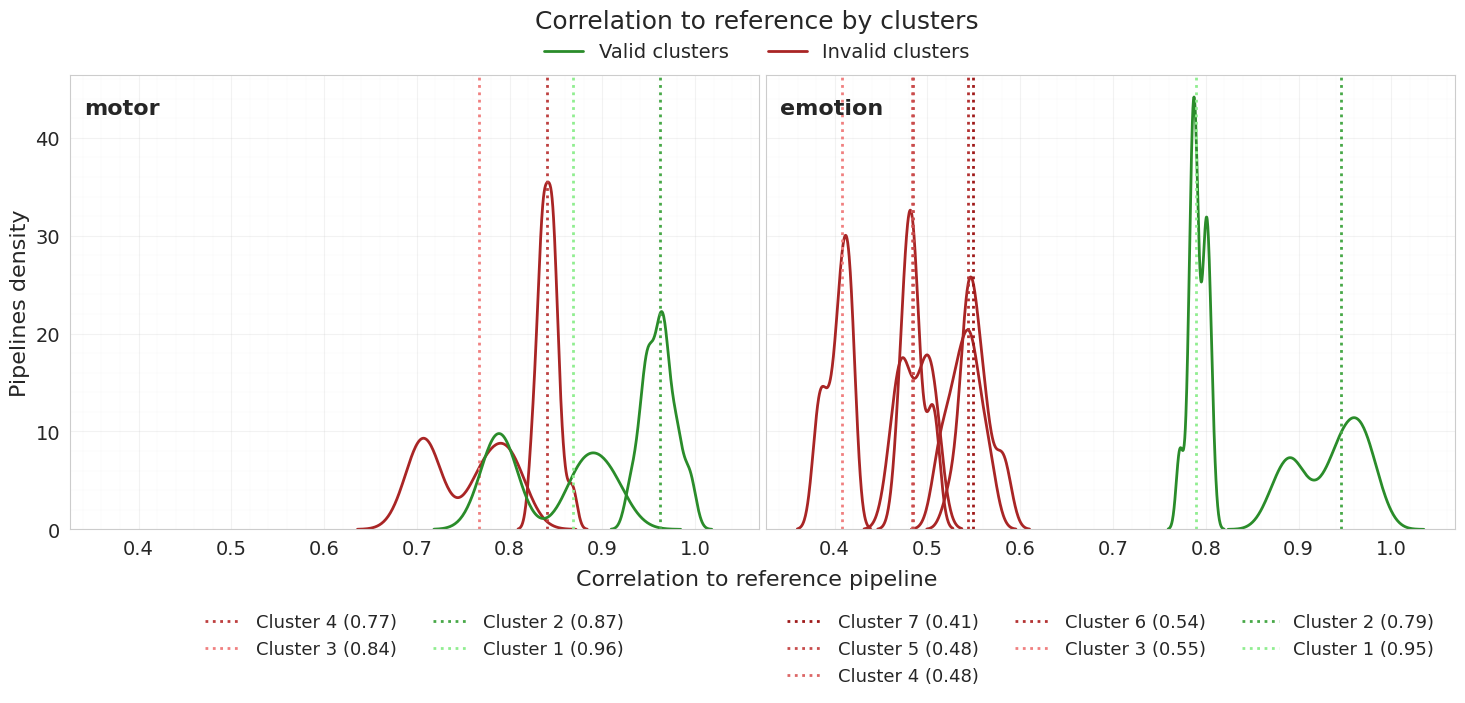

In [10]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from matplotlib.colors import LinearSegmentedColormap
import os

# Define the tasks and their respective directories
tasks = {
    'motor': '/home/ymerel/fmri/OHBM_2026_neurovariants/data/motor_1000',
    'emotion': '/home/ymerel/fmri/OHBM_2026_neurovariants/data/emotion_1000'
}

# Create a figure with two subplots side by side, increased width and height
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True, sharex=True)
fig.suptitle('Correlation to reference by clusters', fontsize=18, y=0.85)

# Define colormaps for green and red shades
green_cmap = LinearSegmentedColormap.from_list('green_shades', ['lightgreen', 'darkgreen'], N=100)
red_cmap = LinearSegmentedColormap.from_list('red_shades', ['lightcoral', 'darkred'], N=100)

plt.rcParams.update({'font.size': 14})

# Use the same shades for the legend as in the plots
valid_shade = green_cmap(0.7)
invalid_shade = red_cmap(0.7)

# Create a single legend for Valid/Invalid (no cluster count)
legend_handles = [
    plt.Line2D([0], [0], color=valid_shade, lw=2, label='Valid clusters'),
    plt.Line2D([0], [0], color=invalid_shade, lw=2, label='Invalid clusters')
]
fig.legend(handles=legend_handles, loc='upper center',
           ncol=2, frameon=False, fontsize=14,
           bbox_to_anchor=(0.5, 0.83))

for i, (task, datadir) in enumerate(tasks.items()):
    datasets = {
        'Valid': pd.read_csv(os.path.join(datadir, 'valid_dataset.csv')),
        'Invalid': pd.read_csv(os.path.join(datadir, 'invalid_dataset.csv'))
    }

    # Dictionary to store stats and medoids
    stats = {}
    medoids = {}

    # Calculate stats and find medoids for each dataset
    for label, df in datasets.items():
        stats[label] = {'mean': df['from_ref'].mean()}
        cluster_medoids = {}
        for cluster in sorted(df['cluster'].unique()):
            cluster_data = df[df['cluster'] == cluster]['from_ref'].values.reshape(-1, 1)
            distances = cdist(cluster_data, cluster_data)
            medoid_idx = np.argmin(distances.sum(axis=1))
            cluster_medoids[int(cluster)] = cluster_data[medoid_idx][0]
        medoids[label] = cluster_medoids

    # Custom legend handles for medoids (to be placed under each subplot)
    medoid_legend_handles = []

    # Plot Invalid and Valid for the current task
    for label in ['Invalid', 'Valid']:
        df = datasets[label]
        cmap = green_cmap if label == 'Valid' else red_cmap

        cluster_color = valid_shade if label == 'Valid' else invalid_shade

        for cluster in sorted(df['cluster'].unique()):
            cluster_data = df[df['cluster'] == cluster]
            sb.kdeplot(
                cluster_data['from_ref'],
                color=cluster_color,
                linewidth=2,
                ax=axes[i]
            )

        # Plot medoids for each cluster (colored to match cluster)
        sorted_medoids = sorted(medoids[label].items(), key=lambda x: x[1])
        for j, (cluster, medoid) in enumerate(sorted_medoids):
            medoid_color = cmap(j / len(sorted_medoids))  # Distinct shade for medoids
            axes[i].axvline(medoid, color=medoid_color, linestyle=':', linewidth=2)

        # Add medoid entries to the legend handles
        for cluster, medoid in sorted_medoids:
            medoid_color = cmap(list(medoids[label].keys()).index(cluster) / len(medoids[label]))
            medoid_legend_handles.append(plt.Line2D([0], [0],
                color=medoid_color,
                linestyle=':', lw=2, label=f'Cluster {cluster} ({medoid:.2f})'))

    # Add task name in the top left or top right of each subplot
    axes[i].text(0.02, 0.95, f'{task}',
                     transform=axes[i].transAxes,
                     fontsize=16, fontweight='bold',
                     verticalalignment='top')

    axes[i].grid(True)

    # Add medoids legend under each subplot
    if len(medoid_legend_handles) == 4:
        cols = 2
    else:
        cols = 3

    axes[i].legend(handles=medoid_legend_handles, loc='upper center',
                   bbox_to_anchor=(0.5, -0.15), ncol=cols, frameon=False, fontsize=13)

# Set y-label only for the left subplot
axes[0].set_ylabel('Pipelines density', fontsize=16)

# Remove x-axis labels for both subplots
for ax in axes:
    ax.set_xlabel('')

    # Major grid
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.25)

    # Minor ticks and grid
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)

    ax.set_axisbelow(True)  # Ensure grid is below data

# Add a single x-axis label centered below both subplots
fig.text(0.5, 0.13, 'Correlation to reference pipeline', ha='center', fontsize=16)

# Adjust layout to maximize plot width and prevent legend clipping
plt.tight_layout(rect=[0.02, 0.05, 0.98, 0.85])
plt.subplots_adjust(wspace=0.01, bottom=0.2)
plt.savefig("corr_to_ref.svg")
plt.show()
